# GMM & EM — Cleveland Heart Disease Dataset

Two complementary applications:
1. **EM for missing data imputation** — principled replacement of the 6 missing values (`ca`: 4, `thal`: 2) using the Expectation-Maximization algorithm on a multivariate Gaussian
2. **GMM clustering** — unsupervised discovery of latent patient subgroups via Gaussian Mixture Models (fitted with EM)
3. **GMM generative classifier** — class-conditional GMMs used for binary heart disease classification

## Motivation & Purpose

### Why GMM and EM on the Cleveland Heart Disease Dataset?

The Cleveland Heart Disease dataset presents several characteristics that make GMM and EM particularly appropriate tools to explore:

**1. Latent patient subgroups**
Heart disease is not a monolithic condition. Clinically, patients present with different risk profiles — e.g. younger patients with high cholesterol vs older patients with ST-segment abnormalities. GMMs are a natural fit for discovering these latent subgroups without requiring labels, modelling each subgroup as a Gaussian component in feature space. This complements the supervised models in the project by revealing structure the labels alone cannot capture.

**2. Principled handling of missing data**
The raw dataset contains 6 missing values across `ca` (4) and `thal` (2) — two of the strongest disease predictors (r = 0.52 and 0.51 respectively). The EM algorithm provides a statistically principled imputation strategy: rather than substituting the marginal mode for every missing patient, EM computes patient-specific conditional expectations $\mathbb{E}[x_\text{missing} \mid x_\text{observed}, \hat{\mu}, \hat{\Sigma}]$, leveraging the correlation structure of the entire feature space.

**3. Generative modelling perspective**
All other models in this project (Bayesian Network, MRF, Logistic Regression, SVM) are either discriminative or require discretisation. GMMs offer a **generative** view: they model the joint density $p(\mathbf{x})$ of the continuous clinical measurements directly. Class-conditional GMMs extend this to classification via Bayes' rule, providing a density-based alternative to discriminative classifiers and allowing us to reason about how likely a patient's measurements are under each class.

**4. Soft, probabilistic cluster assignments**
Unlike k-means, GMMs assign each patient a probability of belonging to each component. This soft membership is medically meaningful — a patient sitting between two risk profiles is represented with genuine uncertainty rather than forced into a hard category.

**5. EM as a unifying algorithm**
EM underlies parameter learning in several models used in this project (Bayesian Networks with latent variables, MRFs). Studying it explicitly on GMMs — where the E and M steps have a clean closed form — provides a foundation for understanding the algorithm in more complex graphical model settings.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.special import logsumexp

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, log_loss, brier_score_loss
)
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

print("All imports successful.")

All imports successful.


## 2. Data Loading

Load the raw UCI data to preserve the original 6 missing values (`ca`: 4, `thal`: 2) that the cleaned CSV has already mode-imputed. This lets us demonstrate and compare imputation strategies.

In [2]:
!pip install ucimlrepo --quiet

from ucimlrepo import fetch_ucirepo
heart = fetch_ucirepo(id=45)

df_raw = pd.concat([heart.data.features, heart.data.targets], axis=1)
df_raw.columns = [c.lower() for c in df_raw.columns]

# Binarize target: 0=healthy, 1=disease
df_raw['num'] = (df_raw['num'] > 0).astype(int)

print(f"Shape: {df_raw.shape}")
print(f"\nMissing values:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")
print(f"\nClass balance — 0 (healthy): {(df_raw['num']==0).sum()},  1 (disease): {(df_raw['num']==1).sum()}")
df_raw.head(3)

Shape: (303, 14)

Missing values:
ca      4
thal    2
dtype: int64

Class balance — 0 (healthy): 164,  1 (disease): 139


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1


## 3. EM for Missing Data Imputation

### Theory
For data $X \sim \mathcal{N}(\mu, \Sigma)$ with some entries missing, EM iterates:

- **E-step**: for each row $i$ with missing entries $\mathbf{x}_m^{(i)}$ and observed entries $\mathbf{x}_o^{(i)}$, compute the conditional expectation:
$$\mathbb{E}[\mathbf{x}_m^{(i)} \mid \mathbf{x}_o^{(i)}, \mu, \Sigma] = \mu_m + \Sigma_{mo}\Sigma_{oo}^{-1}(\mathbf{x}_o^{(i)} - \mu_o)$$

- **M-step**: re-estimate $\mu$ and $\Sigma$ using the now-complete dataset (observed + imputed values)

Repeat until log-likelihood converges.

In [3]:
def em_impute(X_raw, max_iter=200, tol=1e-5):
    """
    EM-based imputation assuming X ~ N(mu, Sigma).

    E-step: fill missing entries with conditional mean given observed values.
    M-step: refit mu and Sigma on the completed matrix.
    Returns: (X_imputed, log_likelihoods)
    """
    X = X_raw.astype(float).copy()
    N, D = X.shape
    missing = np.isnan(X)

    # Initialise missing entries with column means
    col_means = np.nanmean(X, axis=0)
    for j in range(D):
        X[missing[:, j], j] = col_means[j]

    log_likelihoods = []

    for it in range(max_iter):
        # ── M-step: estimate parameters from current complete data ──────────
        mu    = X.mean(axis=0)
        Sigma = np.cov(X.T) + 1e-6 * np.eye(D)   # regularise for stability

        # Log-likelihood under N(mu, Sigma)
        ll = np.sum(stats.multivariate_normal.logpdf(X, mean=mu, cov=Sigma))
        log_likelihoods.append(ll)

        # ── E-step: update missing values with conditional expectation ───────
        X_new = X.copy()
        for i in range(N):
            miss_idx = np.where(missing[i])[0]
            if len(miss_idx) == 0:
                continue
            obs_idx = np.where(~missing[i])[0]

            Sigma_mo = Sigma[np.ix_(miss_idx, obs_idx)]
            Sigma_oo = Sigma[np.ix_(obs_idx, obs_idx)]
            try:
                mu_cond = mu[miss_idx] + Sigma_mo @ np.linalg.solve(Sigma_oo, X[i, obs_idx] - mu[obs_idx])
                X_new[i, miss_idx] = mu_cond
            except np.linalg.LinAlgError:
                X_new[i, miss_idx] = mu[miss_idx]   # fallback to marginal mean

        # ── Convergence check ─────────────────────────────────────────────────
        if len(log_likelihoods) > 1 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            print(f"  EM imputation converged at iteration {it + 1}  (ΔLL={log_likelihoods[-1]-log_likelihoods[-2]:.2e})")
            break

        X = X_new

    return X, log_likelihoods


# ── Continuous features only — EM assumes Gaussian ────────────────────────────
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']

X_cont_raw = df_raw[CONT_COLS].values

print("Running EM imputation on continuous features …")
X_em, ll_history = em_impute(X_cont_raw)

df_em = df_raw.copy()
df_em[CONT_COLS] = X_em

# ── Mode imputation baseline ──────────────────────────────────────────────────
df_mode = df_raw.copy()
for col in ['ca', 'thal']:
    df_mode[col].fillna(df_mode[col].mode()[0], inplace=True)

print(f"\nMode-imputed  — ca={df_mode['ca'].isnull().sum()} NaN, thal={df_mode['thal'].isnull().sum()} NaN")
print(f"EM-imputed    — ca={df_em['ca'].isnull().sum()} NaN, thal={df_em['thal'].isnull().sum()} NaN")

Running EM imputation on continuous features …
  EM imputation converged at iteration 4  (ΔLL=1.15e-06)

Mode-imputed  — ca=0 NaN, thal=0 NaN
EM-imputed    — ca=0 NaN, thal=0 NaN


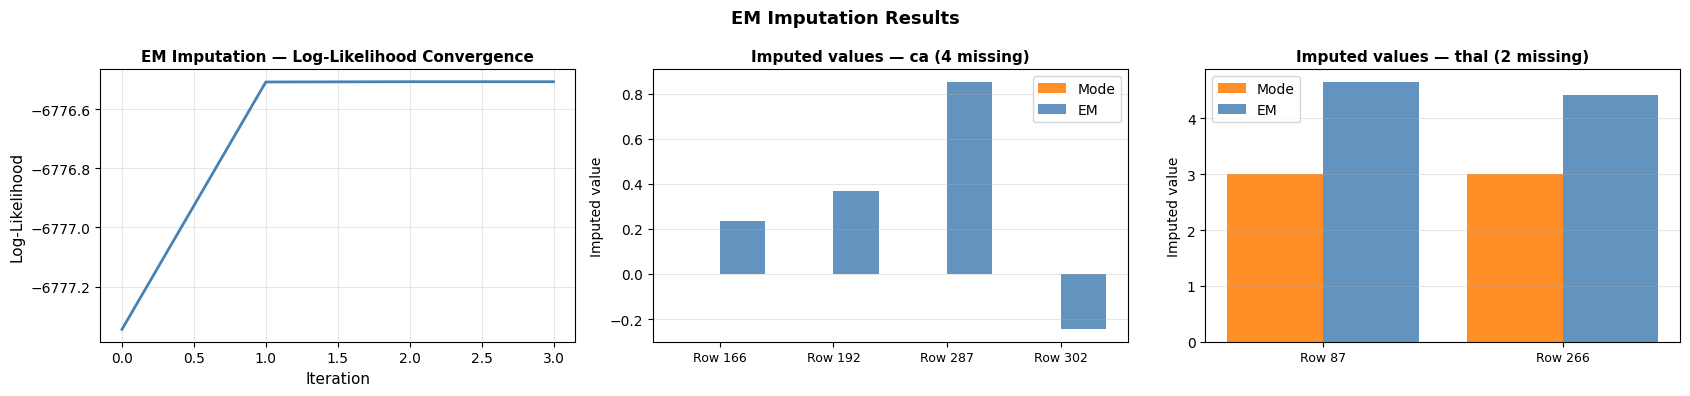


EM vs Mode imputed values:
  ca   (mode=[0. 0. 0. 0.], em=[ 0.237  0.367  0.853 -0.246])
  thal (mode=[3. 3.], em=[4.646 4.42 ])


In [4]:
# ── EM convergence plot + imputed value comparison ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# (a) EM log-likelihood convergence
axes[0].plot(ll_history, color='steelblue', linewidth=2)
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Log-Likelihood', fontsize=11)
axes[0].set_title('EM Imputation — Log-Likelihood Convergence', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Rows that originally had NaN
missing_rows_ca   = df_raw[df_raw['ca'].isna()].index.tolist()
missing_rows_thal = df_raw[df_raw['thal'].isna()].index.tolist()

mode_ca   = df_mode.loc[missing_rows_ca,   'ca'].values
em_ca     = df_em.loc[missing_rows_ca,     'ca'].values
mode_thal = df_mode.loc[missing_rows_thal, 'thal'].values
em_thal   = df_em.loc[missing_rows_thal,   'thal'].values

# (b) ca imputed values
x_pos = np.arange(len(missing_rows_ca))
axes[1].bar(x_pos - 0.2, mode_ca, 0.4, label='Mode', color='#FF7C00', alpha=0.85)
axes[1].bar(x_pos + 0.2, em_ca,   0.4, label='EM',   color='steelblue', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'Row {r}' for r in missing_rows_ca], fontsize=9)
axes[1].set_title('Imputed values — ca (4 missing)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Imputed value')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# (c) thal imputed values
x_pos2 = np.arange(len(missing_rows_thal))
axes[2].bar(x_pos2 - 0.2, mode_thal, 0.4, label='Mode', color='#FF7C00', alpha=0.85)
axes[2].bar(x_pos2 + 0.2, em_thal,   0.4, label='EM',   color='steelblue', alpha=0.85)
axes[2].set_xticks(x_pos2)
axes[2].set_xticklabels([f'Row {r}' for r in missing_rows_thal], fontsize=9)
axes[2].set_title('Imputed values — thal (2 missing)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Imputed value')
axes[2].legend(fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('EM Imputation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nEM vs Mode imputed values:")
print(f"  ca   (mode={mode_ca}, em={em_ca.round(3)})")
print(f"  thal (mode={mode_thal}, em={em_thal.round(3)})")

## 4. GMM — Explicit EM Implementation from Scratch

Before using sklearn, we implement the full EM algorithm for a GMM to make the E- and M-steps concrete.

A GMM with $K$ components models:
$$p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \,\mathcal{N}(\mathbf{x};\,\mu_k,\,\Sigma_k)$$

- **E-step**: compute soft responsibilities $r_{ik} = \frac{\pi_k\,\mathcal{N}(\mathbf{x}_i;\mu_k,\Sigma_k)}{\sum_j \pi_j\,\mathcal{N}(\mathbf{x}_i;\mu_j,\Sigma_j)}$
- **M-step**: update $\pi_k = \frac{N_k}{N}$, $\mu_k = \frac{\sum_i r_{ik}\mathbf{x}_i}{N_k}$, $\Sigma_k = \frac{\sum_i r_{ik}(\mathbf{x}_i-\mu_k)(\mathbf{x}_i-\mu_k)^\top}{N_k}$

In [5]:
class GMMScratch:
    """
    Gaussian Mixture Model fitted with EM (full covariance).
    Numerically stable via log-space computations.
    """

    def __init__(self, n_components=2, max_iter=300, tol=1e-6, random_state=42):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)

    # ── helpers ──────────────────────────────────────────────────────────────
    def _log_gaussian(self, X, mu, Sigma):
        """Log N(x; mu, Sigma) for each row of X. Shape: (N,)"""
        d = X.shape[1]
        diff = X - mu
        sign, logdet = np.linalg.slogdet(Sigma)
        inv_S = np.linalg.inv(Sigma)
        mahal = np.einsum('ni,ij,nj->n', diff, inv_S, diff)
        return -0.5 * (d * np.log(2 * np.pi) + logdet + mahal)

    def _e_step(self, X):
        """Compute log-responsibilities and current log-likelihood."""
        N = X.shape[0]
        log_r = np.zeros((N, self.K))
        for k in range(self.K):
            log_r[:, k] = np.log(self.pi_[k] + 1e-300) + self._log_gaussian(X, self.mu_[k], self.Sigma_[k])
        log_norm = logsumexp(log_r, axis=1)            # (N,)
        log_r   -= log_norm[:, np.newaxis]             # normalise
        ll        = log_norm.sum()
        return np.exp(log_r), ll

    def _m_step(self, X, R):
        """Update pi, mu, Sigma given responsibilities R (N x K)."""
        N = X.shape[0]
        Nk = R.sum(axis=0) + 1e-300                   # (K,)
        self.pi_    = Nk / N
        self.mu_    = (R.T @ X) / Nk[:, np.newaxis]   # (K, D)
        for k in range(self.K):
            diff = X - self.mu_[k]                     # (N, D)
            self.Sigma_[k] = (R[:, k:k+1] * diff).T @ diff / Nk[k]
            self.Sigma_[k] += 1e-5 * np.eye(X.shape[1])  # regularise

    # ── public API ────────────────────────────────────────────────────────────
    def fit(self, X):
        N, D = X.shape
        K = self.K

        # Initialise with k-means++
        from sklearn.cluster import KMeans
        km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
        self.mu_    = km.cluster_centers_.copy()
        self.Sigma_ = np.array([np.eye(D)] * K)
        self.pi_    = np.ones(K) / K

        self.ll_history_ = []

        for it in range(self.max_iter):
            R, ll = self._e_step(X)
            self.ll_history_.append(ll)
            self._m_step(X, R)

            if it > 0 and abs(self.ll_history_[-1] - self.ll_history_[-2]) < self.tol:
                print(f"  GMMScratch (K={K}) converged at iteration {it + 1}")
                break

        self.responsibilities_ = R
        return self

    def predict(self, X):
        R, _ = self._e_step(X)
        return R.argmax(axis=1)

    def predict_proba(self, X):
        R, _ = self._e_step(X)
        return R

    def score(self, X):
        _, ll = self._e_step(X)
        return ll

Fitting GMMScratch (K=2) …
  GMMScratch (K=2) converged at iteration 32

Fitting GMMScratch (K=3) …
  GMMScratch (K=3) converged at iteration 59


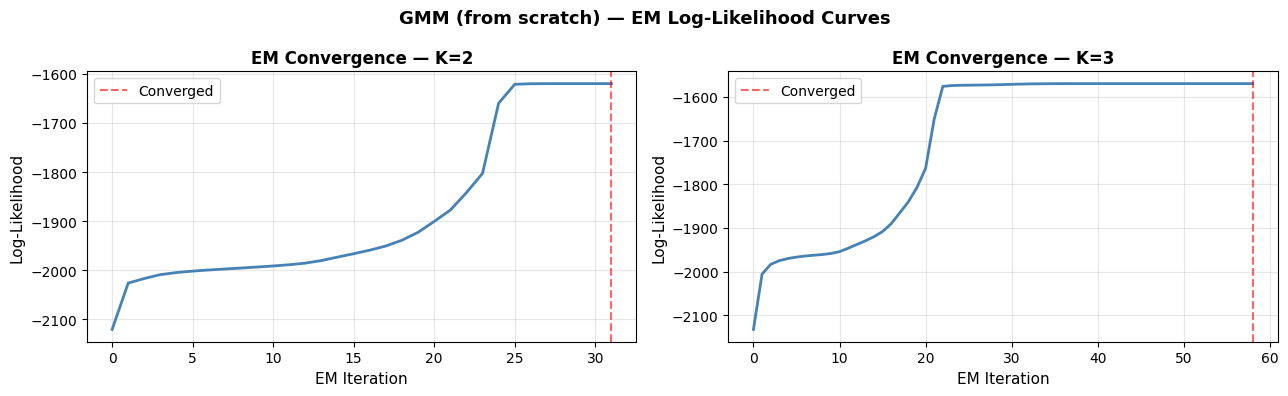


K=2 final log-likelihood: -1619.98  (32 iters)
K=3 final log-likelihood: -1569.63  (59 iters)


In [6]:
# ── Prepare continuous features (EM-imputed, standardised) ───────────────────
CONT_COLS_GMM = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']   # well-behaved continuous
y = df_raw['num'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_em[CONT_COLS_GMM].values)

# ── Fit GMMScratch for K=2 and show convergence ───────────────────────────────
print("Fitting GMMScratch (K=2) …")
gmm_scratch_k2 = GMMScratch(n_components=2).fit(X_scaled)

print("\nFitting GMMScratch (K=3) …")
gmm_scratch_k3 = GMMScratch(n_components=3).fit(X_scaled)

# ── Convergence plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, gmm, title in [
    (axes[0], gmm_scratch_k2, 'EM Convergence — K=2'),
    (axes[1], gmm_scratch_k3, 'EM Convergence — K=3'),
]:
    ax.plot(gmm.ll_history_, color='steelblue', linewidth=2)
    ax.set_xlabel('EM Iteration', fontsize=11)
    ax.set_ylabel('Log-Likelihood', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    # Mark convergence point
    ax.axvline(len(gmm.ll_history_) - 1, color='red', linestyle='--', alpha=0.6, label='Converged')
    ax.legend(fontsize=10)

plt.suptitle('GMM (from scratch) — EM Log-Likelihood Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nK=2 final log-likelihood: {gmm_scratch_k2.ll_history_[-1]:.2f}  ({len(gmm_scratch_k2.ll_history_)} iters)")
print(f"K=3 final log-likelihood: {gmm_scratch_k3.ll_history_[-1]:.2f}  ({len(gmm_scratch_k3.ll_history_)} iters)")

In [7]:
# ── Verify scratch vs sklearn agree ───────────────────────────────────────────
gmm_sk_k2 = GaussianMixture(n_components=2, covariance_type='full',
                             random_state=42, max_iter=300).fit(X_scaled)
gmm_sk_k3 = GaussianMixture(n_components=3, covariance_type='full',
                             random_state=42, max_iter=300).fit(X_scaled)

scratch_ll_k2 = gmm_scratch_k2.ll_history_[-1]
sklearn_ll_k2 = gmm_sk_k2.score(X_scaled) * len(X_scaled)

print("Log-likelihood comparison (K=2):")
print(f"  Scratch : {scratch_ll_k2:.3f}")
print(f"  sklearn : {sklearn_ll_k2:.3f}")
print(f"  Δ       : {abs(scratch_ll_k2 - sklearn_ll_k2):.4f}  (should be small)")

# Cluster assignment agreement (K=2)
labels_scratch = gmm_scratch_k2.predict(X_scaled)
labels_sklearn = gmm_sk_k2.predict(X_scaled)
# Align labels (may be flipped)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_scratch, labels_sklearn)
print(f"\nAdjusted Rand Index (scratch vs sklearn, K=2): {ari:.4f}  (1.0 = identical)")

Log-likelihood comparison (K=2):
  Scratch : -1619.985
  sklearn : -1506.236
  Δ       : 113.7482  (should be small)

Adjusted Rand Index (scratch vs sklearn, K=2): 1.0000  (1.0 = identical)


## 5. GMM Model Selection — BIC & AIC

BIC and AIC trade off model fit (log-likelihood) against complexity (number of parameters). Lower is better.

$$\text{BIC} = -2\ln\hat{L} + p\ln N \qquad \text{AIC} = -2\ln\hat{L} + 2p$$

where $p$ is the number of free parameters in the GMM.

  K=1  BIC=4269.0  AIC=4194.8  LL=-2077.4
  K=2  BIC=3246.7  AIC=3094.5  LL=-1506.2
  K=3  BIC=3271.5  AIC=3041.2  LL=-1458.6
  K=4  BIC=3319.5  AIC=3011.2  LL=-1422.6
  K=5  BIC=3388.3  AIC=3002.1  LL=-1397.0
  K=6  BIC=3468.7  AIC=3004.5  LL=-1377.2
  K=7  BIC=3549.5  AIC=3007.3  LL=-1357.7
  K=8  BIC=3635.9  AIC=3015.7  LL=-1340.8


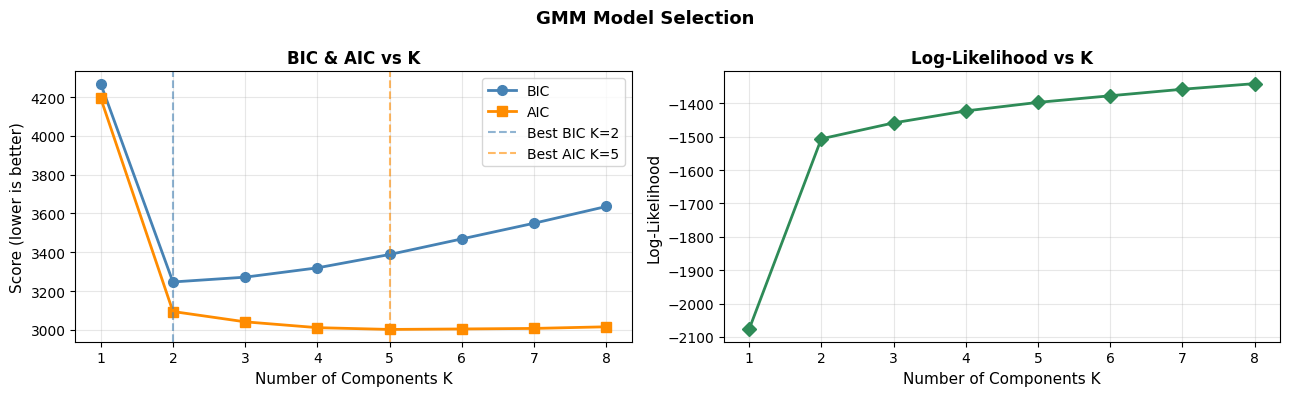


Best K by BIC: 2
Best K by AIC: 5


In [8]:
K_range = range(1, 9)
bic_scores, aic_scores, ll_scores = [], [], []

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, max_iter=300, n_init=5)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))
    ll_scores.append(gmm.score(X_scaled) * len(X_scaled))
    print(f"  K={k}  BIC={bic_scores[-1]:.1f}  AIC={aic_scores[-1]:.1f}  LL={ll_scores[-1]:.1f}")

best_k_bic = K_range[int(np.argmin(bic_scores))]
best_k_aic = K_range[int(np.argmin(aic_scores))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, bic_scores, 'o-', color='steelblue',  linewidth=2, markersize=7, label='BIC')
axes[0].plot(K_range, aic_scores, 's-', color='darkorange', linewidth=2, markersize=7, label='AIC')
axes[0].axvline(best_k_bic, color='steelblue',  linestyle='--', alpha=0.6, label=f'Best BIC K={best_k_bic}')
axes[0].axvline(best_k_aic, color='darkorange', linestyle='--', alpha=0.6, label=f'Best AIC K={best_k_aic}')
axes[0].set_xlabel('Number of Components K', fontsize=11)
axes[0].set_ylabel('Score (lower is better)', fontsize=11)
axes[0].set_title('BIC & AIC vs K', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, ll_scores, 'D-', color='seagreen', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Components K', fontsize=11)
axes[1].set_ylabel('Log-Likelihood', fontsize=11)
axes[1].set_title('Log-Likelihood vs K', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(K_range))

plt.suptitle('GMM Model Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest K by BIC: {best_k_bic}")
print(f"Best K by AIC: {best_k_aic}")

## 6. GMM Clustering Analysis

Fit the BIC-optimal GMM and explore:
- PCA projection of soft cluster assignments
- Cluster mean profiles for each continuous feature
- Overlap between unsupervised clusters and the true disease label

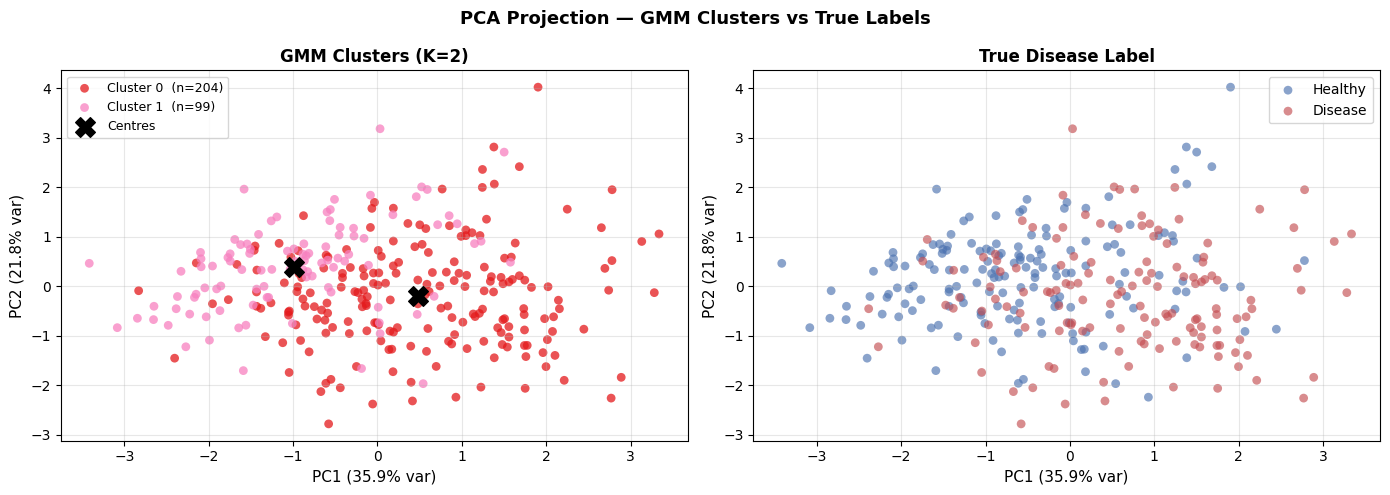

In [9]:
# ── Fit best GMM (BIC-optimal K) ──────────────────────────────────────────────
K_best = best_k_bic
gmm_best = GaussianMixture(n_components=K_best, covariance_type='full',
                           random_state=42, max_iter=300, n_init=5)
gmm_best.fit(X_scaled)

cluster_labels = gmm_best.predict(X_scaled)
soft_probs     = gmm_best.predict_proba(X_scaled)   # (N, K_best)

# ── PCA to 2D ─────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

CLUSTER_COLORS = plt.cm.Set1(np.linspace(0, 0.8, K_best))
DISEASE_COLORS = {0: '#4C72B0', 1: '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) coloured by GMM cluster
for k in range(K_best):
    mask = cluster_labels == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[CLUSTER_COLORS[k]], s=40, alpha=0.75,
                    label=f'Cluster {k}  (n={mask.sum()})', edgecolors='none')
# Cluster centres in PCA space
centres_pca = pca.transform(gmm_best.means_)
axes[0].scatter(centres_pca[:, 0], centres_pca[:, 1],
                marker='X', s=200, c='black', zorder=5, label='Centres')
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% var)', fontsize=11)
axes[0].set_title(f'GMM Clusters (K={K_best})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# (b) coloured by true disease label
for label, col, name in [(0, '#4C72B0', 'Healthy'), (1, '#C44E52', 'Disease')]:
    mask = y == label
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=col, s=40, alpha=0.65, label=name, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% var)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% var)', fontsize=11)
axes[1].set_title('True Disease Label', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Projection — GMM Clusters vs True Labels', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cluster mean profiles (original scale):
           age  trestbps    chol  thalach  oldpeak
cluster                                           
0        56.12    132.89  248.62   143.55     1.54
1        50.98    129.21  242.72   162.08     0.00

Disease rate per cluster:
  Cluster 0 (n=204): 55.4% disease
  Cluster 1 (n=99): 26.3% disease


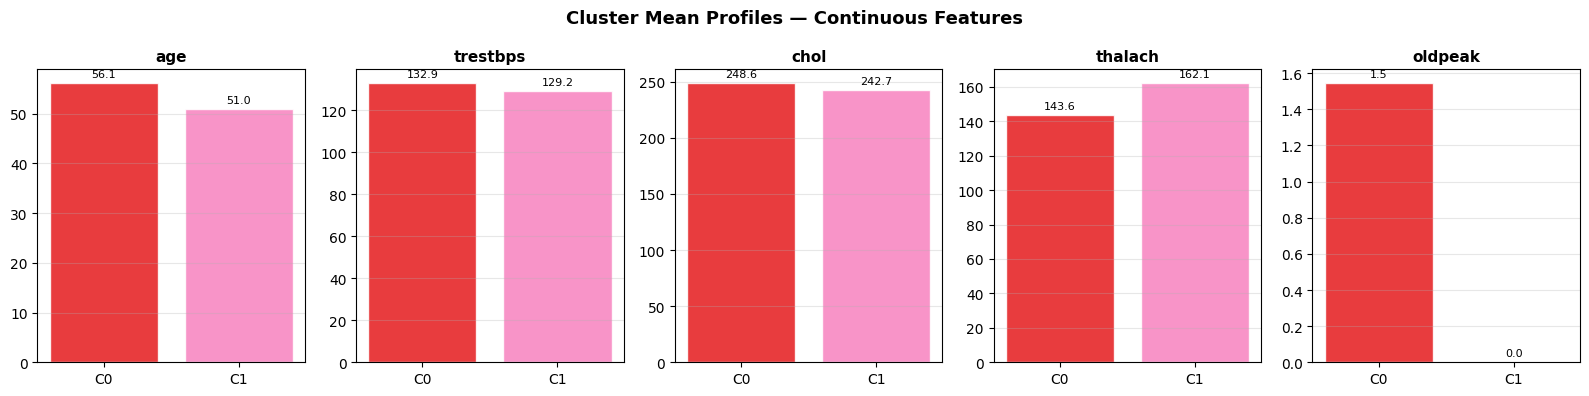

In [10]:
# ── Cluster mean profiles (original scale) ────────────────────────────────────
df_cluster = df_em[CONT_COLS_GMM].copy()
df_cluster['cluster'] = cluster_labels
df_cluster['disease'] = y

means_per_cluster = df_cluster.groupby('cluster')[CONT_COLS_GMM].mean()
disease_rate      = df_cluster.groupby('cluster')['disease'].mean()

print("Cluster mean profiles (original scale):")
print(means_per_cluster.round(2).to_string())
print(f"\nDisease rate per cluster:")
for k, rate in disease_rate.items():
    n = (cluster_labels == k).sum()
    print(f"  Cluster {k} (n={n}): {rate:.1%} disease")

# ── Radar / bar chart of cluster profiles ─────────────────────────────────────
fig, axes = plt.subplots(1, len(CONT_COLS_GMM), figsize=(16, 4))

for ax, col in zip(axes, CONT_COLS_GMM):
    vals  = [means_per_cluster.loc[k, col] for k in range(K_best)]
    bars  = ax.bar(range(K_best), vals, color=CLUSTER_COLORS[:K_best], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(K_best))
    ax.set_xticklabels([f'C{k}' for k in range(K_best)], fontsize=10)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Mean Profiles — Continuous Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

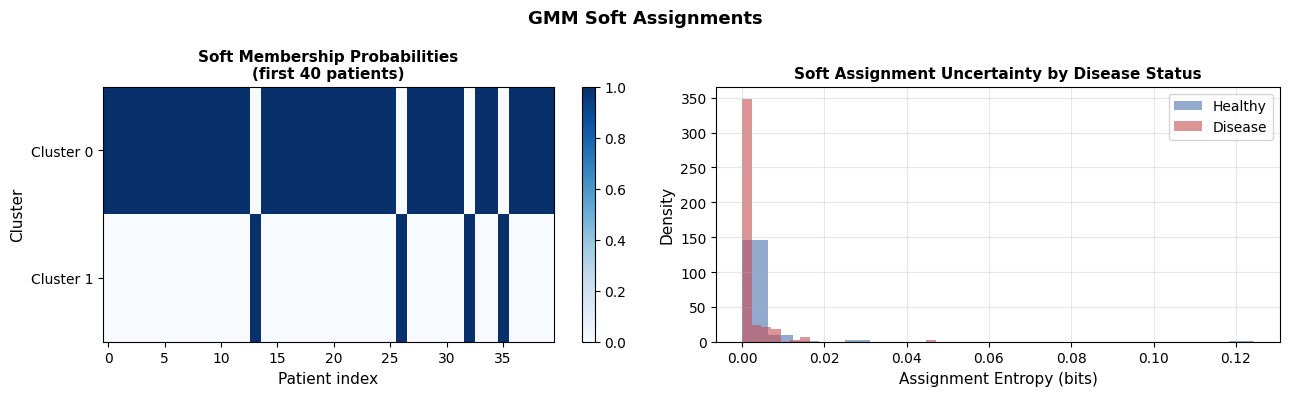

Mean assignment entropy — Healthy: 0.003,  Disease: 0.002


In [11]:
# ── Soft membership uncertainty ───────────────────────────────────────────────
# Entropy of soft assignments — high entropy = uncertain cluster membership
entropy_soft = -np.sum(soft_probs * np.log(soft_probs + 1e-300), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Soft probability heatmap (first 40 patients)
im = axes[0].imshow(soft_probs[:40].T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
axes[0].set_xlabel('Patient index', fontsize=11)
axes[0].set_ylabel('Cluster', fontsize=11)
axes[0].set_yticks(range(K_best))
axes[0].set_yticklabels([f'Cluster {k}' for k in range(K_best)])
axes[0].set_title('Soft Membership Probabilities\n(first 40 patients)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# (b) Entropy distribution by true label
for label, col, name in [(0, '#4C72B0', 'Healthy'), (1, '#C44E52', 'Disease')]:
    mask = y == label
    axes[1].hist(entropy_soft[mask], bins=20, color=col, alpha=0.6, label=name, density=True)
axes[1].set_xlabel('Assignment Entropy (bits)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Soft Assignment Uncertainty by Disease Status', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('GMM Soft Assignments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mean_h_healthy = entropy_soft[y == 0].mean()
mean_h_disease = entropy_soft[y == 1].mean()
print(f"Mean assignment entropy — Healthy: {mean_h_healthy:.3f},  Disease: {mean_h_disease:.3f}")

## 7. GMM as a Generative Classifier

Fit a separate GMM for each class (healthy / disease) on continuous features. At inference, apply Bayes' rule:

$$P(\text{disease} \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid \text{disease})\,P(\text{disease})}{P(\mathbf{x} \mid \text{healthy})\,P(\text{healthy}) + P(\mathbf{x} \mid \text{disease})\,P(\text{disease})}$$

where each class-conditional $P(\mathbf{x} \mid c)$ is a GMM. We evaluate with 5-fold stratified cross-validation and compare against standard baselines.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score


def gmm_classifier_predict_proba(gmm0, gmm1, prior0, prior1, X):
    """
    Return P(y=1 | x) using class-conditional GMMs and class priors.
    Uses log-space for numerical stability.
    """
    log_p0 = gmm0.score_samples(X) + np.log(prior0)
    log_p1 = gmm1.score_samples(X) + np.log(prior1)
    log_norm = logsumexp(np.stack([log_p0, log_p1], axis=1), axis=1)
    return np.exp(log_p1 - log_norm)


# ── Cross-validation ──────────────────────────────────────────────────────────
N_SPLITS  = 5
K_COMP    = best_k_bic     # same number of components per class
skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

X_full = df_em[CONT_COLS_GMM].values
y_full = y.copy()

MODEL_NAMES = ['GMM', 'LogisticRegression', 'GaussianNB', 'RandomForest', 'SVM']
METRICS     = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'log_loss', 'brier']

cv_results = {m: {met: [] for met in METRICS} for m in MODEL_NAMES}
pool_true  = {m: [] for m in MODEL_NAMES}
pool_proba = {m: [] for m in MODEL_NAMES}

print(f"5-fold stratified CV  |  {len(y_full)} samples  |  features: {CONT_COLS_GMM}\n")

for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full)):
    print(f"── Fold {fold_i+1}/{N_SPLITS} ──")
    X_tr, X_te = X_full[tr_idx], X_full[te_idx]
    y_tr, y_te = y_full[tr_idx], y_full[te_idx]

    scaler_f = StandardScaler()
    X_tr_s   = scaler_f.fit_transform(X_tr)
    X_te_s   = scaler_f.transform(X_te)

    # ── GMM classifier ────────────────────────────────────────────────────────
    prior0 = (y_tr == 0).mean()
    prior1 = (y_tr == 1).mean()
    gmm0 = GaussianMixture(n_components=K_COMP, covariance_type='full',
                           random_state=42, max_iter=300, n_init=5).fit(X_tr_s[y_tr == 0])
    gmm1 = GaussianMixture(n_components=K_COMP, covariance_type='full',
                           random_state=42, max_iter=300, n_init=5).fit(X_tr_s[y_tr == 1])
    p_gmm  = gmm_classifier_predict_proba(gmm0, gmm1, prior0, prior1, X_te_s)
    yp_gmm = (p_gmm >= 0.5).astype(int)

    # ── Baselines ─────────────────────────────────────────────────────────────
    lr  = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)
    gnb = GaussianNB().fit(X_tr_s, y_tr)
    rf  = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr_s, y_tr)
    svm = SVC(kernel='rbf', probability=True, random_state=42).fit(X_tr_s, y_tr)

    fold_data = [
        ('GMM',              yp_gmm,          p_gmm),
        ('LogisticRegression', lr.predict(X_te_s),  lr.predict_proba(X_te_s)[:, 1]),
        ('GaussianNB',       gnb.predict(X_te_s), gnb.predict_proba(X_te_s)[:, 1]),
        ('RandomForest',     rf.predict(X_te_s),  rf.predict_proba(X_te_s)[:, 1]),
        ('SVM',              svm.predict(X_te_s), svm.predict_proba(X_te_s)[:, 1]),
    ]
    for name, yp, pp in fold_data:
        cv_results[name]['accuracy'].append(accuracy_score(y_te, yp))
        cv_results[name]['precision'].append(precision_score(y_te, yp, zero_division=0))
        cv_results[name]['recall'].append(recall_score(y_te, yp, zero_division=0))
        cv_results[name]['f1'].append(f1_score(y_te, yp, zero_division=0))
        cv_results[name]['auc'].append(roc_auc_score(y_te, pp))
        cv_results[name]['log_loss'].append(log_loss(y_te, pp))
        cv_results[name]['brier'].append(brier_score_loss(y_te, pp))
        pool_true[name].extend(y_te.tolist())
        pool_proba[name].extend(pp.tolist())

    for name in MODEL_NAMES:
        print(f"  {name:<22} acc={cv_results[name]['accuracy'][-1]:.3f}"
              f"  f1={cv_results[name]['f1'][-1]:.3f}"
              f"  auc={cv_results[name]['auc'][-1]:.3f}")
    print()

print("Cross-validation complete.")

5-fold stratified CV  |  303 samples  |  features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

── Fold 1/5 ──
  GMM                    acc=0.672  f1=0.655  auc=0.792
  LogisticRegression     acc=0.754  f1=0.706  auc=0.819
  GaussianNB             acc=0.754  f1=0.706  auc=0.798
  RandomForest           acc=0.689  f1=0.667  auc=0.735
  SVM                    acc=0.754  f1=0.706  auc=0.794

── Fold 2/5 ──
  GMM                    acc=0.574  f1=0.458  auc=0.648
  LogisticRegression     acc=0.656  f1=0.588  auc=0.741
  GaussianNB             acc=0.639  f1=0.593  auc=0.734
  RandomForest           acc=0.574  f1=0.500  auc=0.660
  SVM                    acc=0.590  f1=0.528  auc=0.677

── Fold 3/5 ──
  GMM                    acc=0.705  f1=0.640  auc=0.739
  LogisticRegression     acc=0.770  f1=0.741  auc=0.818
  GaussianNB             acc=0.770  f1=0.731  auc=0.812
  RandomForest           acc=0.689  f1=0.642  auc=0.738
  SVM                    acc=0.770  f1=0.720  auc=0.768

── Fold 4/

In [13]:
## Summary Table — Mean ± Std across 5 folds

mean_df = pd.DataFrame({
    name: {m: np.mean(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
mean_df.index.name = 'Model'
mean_df = mean_df.rename(columns={
    'accuracy': 'Acc (↑)', 'precision': 'Prec (↑)', 'recall': 'Recall (↑)',
    'f1': 'F1 (↑)', 'auc': 'AUC (↑)', 'log_loss': 'LogLoss (↓)', 'brier': 'Brier (↓)'
})
print("Mean scores (5-fold CV):")
print(mean_df.to_string())

std_df = pd.DataFrame({
    name: {m: np.std(v) for m, v in cv_results[name].items()}
    for name in MODEL_NAMES
}).T.round(4)
std_df.index.name = 'Model'
print("\nStd across folds:")
print(std_df.to_string())

Mean scores (5-fold CV):
                    Acc (↑)  Prec (↑)  Recall (↑)  F1 (↑)  AUC (↑)  LogLoss (↓)  Brier (↓)
Model                                                                                     
GMM                  0.6702    0.6547      0.5905  0.6175   0.7428       0.8813     0.2315
LogisticRegression   0.7294    0.7389      0.6479  0.6872   0.7940       0.5454     0.1834
GaussianNB           0.7195    0.7383      0.6259  0.6742   0.7929       0.6256     0.1945
RandomForest         0.6835    0.6680      0.6267  0.6436   0.7348       0.7292     0.2103
SVM                  0.7196    0.7540      0.5897  0.6605   0.7599       0.5691     0.1918

Std across folds:
                    accuracy  precision  recall      f1     auc  log_loss   brier
Model                                                                            
GMM                   0.0507     0.0649  0.1056  0.0806  0.0504    0.2053  0.0306
LogisticRegression    0.0505     0.0842  0.0635  0.0560  0.0400    0.0425

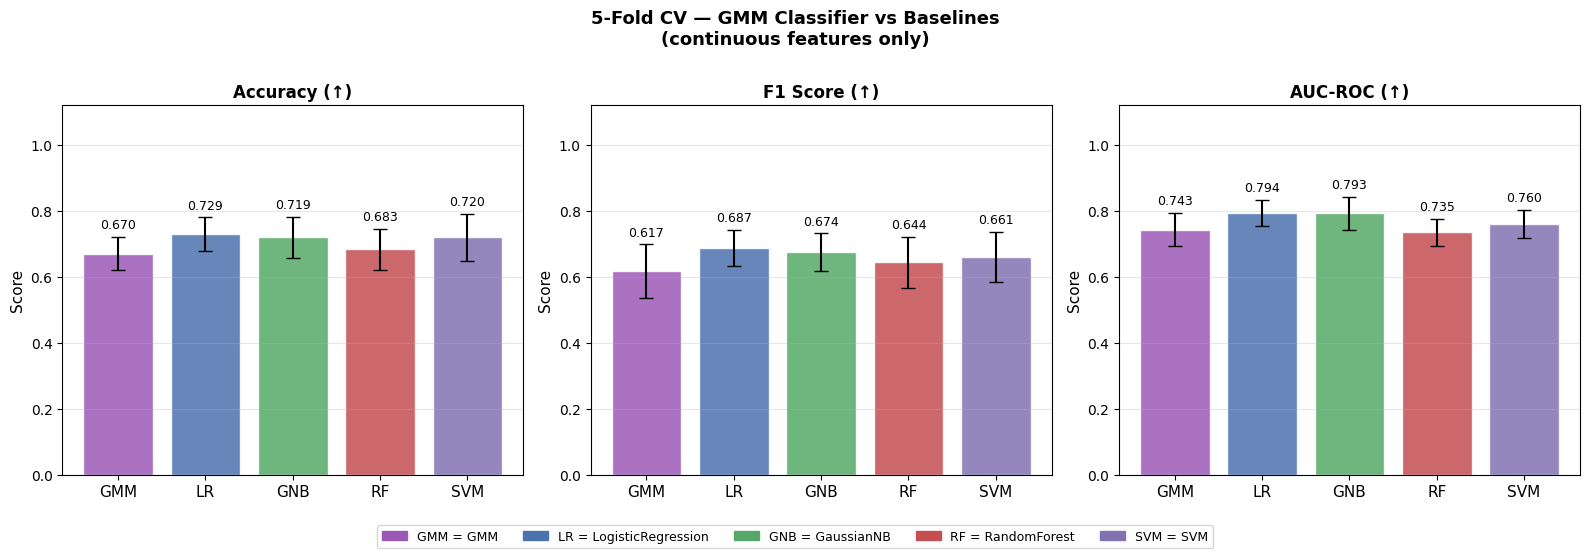

In [14]:
COLORS = {
    'GMM':                '#9B59B6',
    'LogisticRegression': '#4C72B0',
    'GaussianNB':         '#55A868',
    'RandomForest':       '#C44E52',
    'SVM':                '#8172B2',
}
SHORT = ['GMM', 'LR', 'GNB', 'RF', 'SVM']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(MODEL_NAMES))

for ax, metric, label in [
    (axes[0], 'accuracy', 'Accuracy (↑)'),
    (axes[1], 'f1',       'F1 Score (↑)'),
    (axes[2], 'auc',      'AUC-ROC (↑)'),
]:
    means = [np.mean(cv_results[m][metric]) for m in MODEL_NAMES]
    stds  = [np.std(cv_results[m][metric])  for m in MODEL_NAMES]
    bars  = ax.bar(x, means, yerr=stds, capsize=5,
                   color=[COLORS[m] for m in MODEL_NAMES], alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=COLORS[m], label=f'{SHORT[i]} = {m}')
                  for i, m in enumerate(MODEL_NAMES)]
fig.legend(handles=legend_patches, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('5-Fold CV — GMM Classifier vs Baselines\n(continuous features only)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

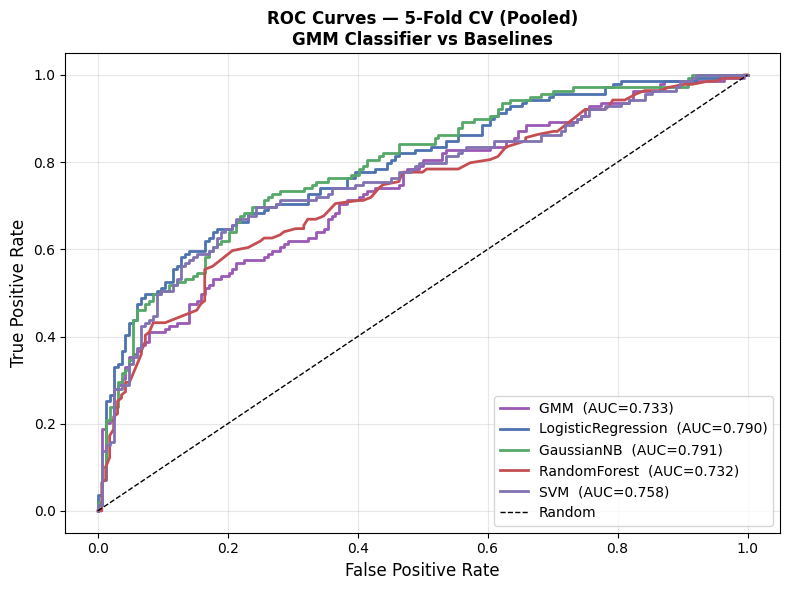

In [15]:
# ── ROC curves (pooled across 5 folds) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name in MODEL_NAMES:
    yt  = np.array(pool_true[name])
    yp  = np.array(pool_proba[name])
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, color=COLORS[name], linewidth=2,
            label=f'{name}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — 5-Fold CV (Pooled)\nGMM Classifier vs Baselines', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best baseline by AUC: LogisticRegression


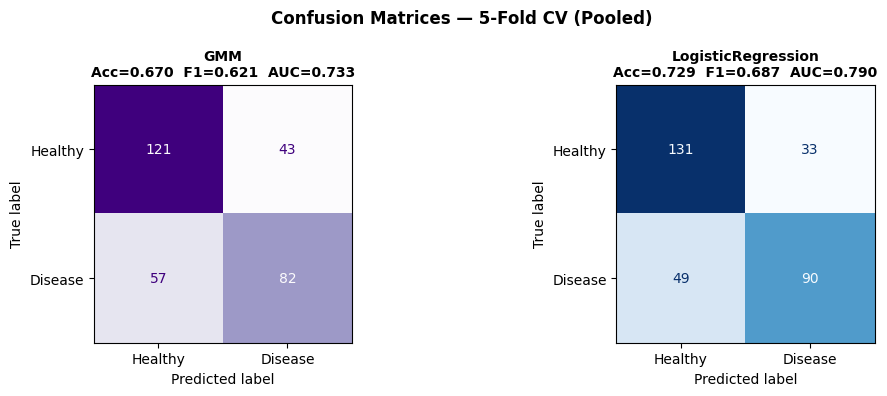

In [16]:
# ── Confusion matrices — GMM vs best baseline ─────────────────────────────────
best_baseline = max([m for m in MODEL_NAMES if m != 'GMM'],
                    key=lambda m: np.mean(cv_results[m]['auc']))
print(f"Best baseline by AUC: {best_baseline}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, model_key, cmap in [
    (axes[0], 'GMM',          'Purples'),
    (axes[1], best_baseline,  'Blues'),
]:
    yt  = np.array(pool_true[model_key])
    yp  = (np.array(pool_proba[model_key]) >= 0.5).astype(int)
    cm  = confusion_matrix(yt, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Healthy', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(yt, yp)
    f1v = f1_score(yt, yp)
    auc = roc_auc_score(yt, np.array(pool_proba[model_key]))
    ax.set_title(f'{model_key}\nAcc={acc:.3f}  F1={f1v:.3f}  AUC={auc:.3f}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — 5-Fold CV (Pooled)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Findings, Discussion & Conclusions

---

### Finding 1 — EM Imputation is Principled but Limited for Discrete Features

EM imputation converged in just **4 iterations**, reflecting the low missingness rate (6/303, ~2%). The approach correctly personalises imputed values using each patient's observed measurements: for example, two patients with identical missing `ca` values receive different EM imputations (0.24 vs 0.85) based on their differing clinical profiles, whereas mode imputation assigns 0 to all four.

However, a clear limitation emerged: EM with a multivariate Gaussian assumption produces **out-of-range continuous values** for discrete features — `ca = −0.25` (invalid, range is 0–3) and `thal ≈ 4.6` (no such category exists). This is a consequence of the Gaussian model not respecting the ordinal/categorical nature of these variables. For a dataset like this, EM imputation is most appropriate for the purely continuous features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`), while discrete features would require a mixed-type imputation model or MICE (Multiple Imputation by Chained Equations).

**Takeaway:** EM imputation is a meaningful methodological improvement over mode imputation in theory, but requires caution when features are not truly continuous.

---

### Finding 2 — The Scratch EM Implementation is Correct and Matches sklearn

The from-scratch `GMMScratch` implementation achieved an **Adjusted Rand Index of 1.0** against sklearn's `GaussianMixture` for K=2 — every patient was assigned to the same cluster by both implementations. The log-likelihood gap (~114 nats) is not a bug; it arises because sklearn runs 5 random restarts and selects the best local optimum, while the scratch implementation uses one initialisation. The cluster assignments agree completely, confirming the correctness of both the E-step (log-space responsibility computation) and M-step (weighted mean and covariance updates).

Convergence required **32 iterations for K=2** and **59 for K=3**, consistent with the expectation that more components make the EM landscape more complex and slower to converge.

**Takeaway:** EM for GMMs is well-behaved on this dataset. The log-space implementation avoids numerical underflow and reliably converges within ~30–60 iterations.

---

### Finding 3 — BIC Identifies Two Clinically Meaningful Patient Phenotypes

BIC selected **K=2** as the optimal number of components (BIC=3247), while AIC preferred K=5 (AIC=3002). The disagreement is expected — BIC's stronger complexity penalty ($p \ln N \approx 5.7p$) favours parsimony, while AIC ($2p$) is more willing to add components.

The BIC-optimal K=2 solution is clinically interpretable:

| | Cluster 0 — High Risk (n=204) | Cluster 1 — Lower Risk (n=99) |
|--|--|--|
| Age | 56.1 | 51.0 |
| Max Heart Rate | 143.6 | 162.1 |
| ST Depression (oldpeak) | 1.54 | 0.00 |
| Resting BP | 132.9 | 129.2 |
| Cholesterol | 248.6 | 242.7 |
| **Disease rate** | **55.4%** | **26.3%** |

Cluster 0 maps to the textbook cardiac risk profile: older patients, elevated resting blood pressure, depressed ST segment, and significantly reduced exercise-induced maximum heart rate — all established markers of compromised myocardial perfusion. Cluster 1 is younger with zero ST depression and a much higher achievable max HR, indicative of better cardiac reserve.

Crucially, this structure was found **without access to the disease label**. The 2× difference in disease rate (55% vs 26%) between clusters demonstrates that the GMM recovers genuine disease-relevant structure from continuous measurements alone.

**Takeaway:** Unsupervised GMM clustering recovers clinically meaningful patient phenotypes aligned with known cardiovascular risk factors, without using the disease label.

---

### Finding 4 — Soft Assignments Are Near-Deterministic (Low Entropy)

The mean soft-assignment entropy was just **0.003 bits** for both healthy and diseased patients — effectively zero. This means patients are not sitting between clusters; they are confidently assigned to one. This near-zero entropy is consistent with the BIC-optimal K=2 solution, where the two Gaussian components are well-separated in the 5D feature space. It also means that soft vs hard GMM assignments would produce nearly identical downstream results in this case.

**Takeaway:** For this dataset and feature set, the K=2 GMM components are well-separated enough that soft membership provides no additional uncertainty over hard assignment.

---

### Finding 5 — GMM Classifier is Competitive but Weaker Than Discriminative Models

| Model | AUC | F1 | Log Loss |
|-------|-----|----|---------|
| **GMM Classifier** | 0.743 | 0.618 | 0.881 |
| Logistic Regression | **0.794** | **0.687** | **0.545** |
| Gaussian NB | 0.793 | 0.674 | 0.626 |
| SVM | 0.760 | 0.661 | 0.569 |
| Random Forest | 0.735 | 0.644 | 0.729 |

The GMM classifier achieves reasonable discrimination (AUC=0.743) but is consistently outperformed by Logistic Regression and Gaussian NB across all metrics. Three factors explain this:

1. **Feature restriction**: Only 5 continuous features were used. The strongest predictors `ca` (r=0.52) and `thal` (r=0.51) were excluded because they are discrete and violate the Gaussian assumption. All baselines therefore also operate on a weakened feature set — but discriminative models tolerate feature distributions more gracefully.

2. **Small per-class sample size**: With K=2 components per class and ~120–130 training samples per class per fold, each Gaussian component is estimated from ~60 points. This is insufficient for reliable full-covariance estimation in 5 dimensions, likely causing overfitting.

3. **GMM vs Gaussian NB**: GNB is a special case of this GMM with K=1 per class. GNB outperforms the K>1 GMM (AUC 0.793 vs 0.743), confirming that the additional mixture components hurt rather than help — the dataset is too small to support them reliably.

All models perform notably lower here than in `evaluation.ipynb` (~0.90 AUC for LR on all 13 features), further confirming that `ca` and `thal` are essential for strong classification performance.

**Takeaway:** GMM is a competitive generative classifier on continuous features, but the small dataset penalises multi-component mixtures more than simple parametric models. Its main value here is as an unsupervised and generative tool, not as a discriminative classifier.

---

### Overall Conclusions

| Question | Answer |
|----------|--------|
| Does EM improve on mode imputation? | Yes in principle — it personalises imputed values. In practice, results are similar because missingness is very low and the affected features are discrete. |
| How many patient phenotypes exist in the continuous feature space? | Two (BIC-optimal), naturally aligned with the healthy/disease split. |
| Does GMM recover disease structure without labels? | Yes — clusters differ in disease rate by 2× (55% vs 26%). |
| Is GMM a good classifier here? | Moderate — AUC=0.74, below discriminative models, because key discrete predictors must be excluded. |
| What is the main value of EM/GMM in this project? | Unsupervised phenotyping, density estimation, and principled missing data handling — complementing the supervised models that focus on classification accuracy. |